####  Importer les bibliothèques nécessaires


In [1]:
import numpy as np
import pandas
import numpy as vnp
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv('C:\\Users\\ec\\OneDrive\\Bureau\\PROJET_MLOPS\\Loan_Data.csv')


#### Afficher les premières lignes du DataFrame pour inspecter les données

In [3]:
print("Aperçu des données :")
print(df.head())

Aperçu des données :
   customer_id  credit_lines_outstanding  loan_amt_outstanding  \
0      8153374                         0           5221.545193   
1      7442532                         5           1958.928726   
2      2256073                         0           3363.009259   
3      4885975                         0           4766.648001   
4      4700614                         1           1345.827718   

   total_debt_outstanding       income  years_employed  fico_score  default  
0             3915.471226  78039.38546               5         605        0  
1             8228.752520  26648.43525               2         572        1  
2             2027.830850  65866.71246               4         602        0  
3             2501.730397  74356.88347               5         612        0  
4             1768.826187  23448.32631               6         631        0  


####    Gérer les valeurs manquantes

In [4]:
# Méthode : Remplacer les valeurs manquantes par la médiane (pour les variables numériques) et par le mode (pour les variables catégorielles)
for column in df.columns:
    if df[column].dtype == 'object':  # Si la colonne est catégorielle
        df[column].fillna(df[column].mode()[0], inplace=True)  # Remplacer par le mode
    else:
        df[column].fillna(df[column].median(), inplace=True)  # Remplacer par la médiane


C:\Users\ec\AppData\Local\Temp\ipykernel_20136\459154469.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[column].fillna(df[column].median(), inplace=True)  # Remplacer par la médiane
C:\Users\ec\AppData\Local\Temp\ipykernel_20136\459154469.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always beh

In [5]:
# Vérifier s'il reste des valeurs manquantes
print("\nValeurs manquantes après traitement :")
print(df.isnull().sum())


Valeurs manquantes après traitement :
customer_id                 0
credit_lines_outstanding    0
loan_amt_outstanding        0
total_debt_outstanding      0
income                      0
years_employed              0
fico_score                  0
default                     0
dtype: int64


Cela signifie que toutes les informations nécessaires sont maintenant présentes pour chaque client dans ces colonnes.

### Pré-traitement des données

#### Encodage des variables catégorielles

In [6]:
# Utilisation de LabelEncoder pour transformer les colonnes catégorielles en valeurs numériques
label_encoders = {}
for column in df.columns:
    if df[column].dtype == 'object':
        le = LabelEncoder()
        df[column] = le.fit_transform(df[column])
        label_encoders[column] = le


#### Normalisation ou standardisation

In [7]:
df.to_csv('Loan_Data_Preprocessed_v2.csv', index=False)


In [8]:
import pandas as pd

# Charger les données
df = pd.read_csv('C:/Users/ec/OneDrive/Bureau/PROJET_MLOPS/Loan_Data.csv')

# Prétraitement des données
# (Ajoutez ici votre code de prétraitement)

# Afficher les premières lignes du DataFrame
print(df.head())

# Sauvegarder les données pré-traitées dans un nouveau fichier CSV
output_path = 'C:/Users/ec/Documents/Loan_Data_Preprocessedv2.csv'
df.to_csv(output_path, index=False)
print(f"\nLes données pré-traitées ont été enregistrées dans '{output_path}'.")


   customer_id  credit_lines_outstanding  loan_amt_outstanding  \
0      8153374                         0           5221.545193   
1      7442532                         5           1958.928726   
2      2256073                         0           3363.009259   
3      4885975                         0           4766.648001   
4      4700614                         1           1345.827718   

   total_debt_outstanding       income  years_employed  fico_score  default  
0             3915.471226  78039.38546               5         605        0  
1             8228.752520  26648.43525               2         572        1  
2             2027.830850  65866.71246               4         602        0  
3             2501.730397  74356.88347               5         612        0  
4             1768.826187  23448.32631               6         631        0  

Les données pré-traitées ont été enregistrées dans 'C:/Users/ec/Documents/Loan_Data_Preprocessedv2.csv'.


### Model Engineering

In [9]:
# Supprimer la colonne 'customer_id' qui n'est pas pertinente pour la classification
df_cleaned = df.drop(columns=['customer_id'])

La colonne customer_id est un identifiant unique pour chaque client dans le dataset. Elle n'apporte aucune information utile pour la classification des prêts en défaut  - non-défaut parce qu'elle ne représente aucune caractéristique du client qui pourrait influencer le résultat

#### Séparation des caratéristiques et des variables cibles 

In [10]:
# Convertir la variable cible en catégorielle binaire si nécessaire
df_cleaned['default'] = df_cleaned['default'].astype('category')

# Compter les occurrences des catégories
default_counts = df_cleaned['default'].value_counts()
print(default_counts)


default
0    8149
1    1851
Name: count, dtype: int64


In [11]:
# Séparer les caractéristiques (X) et la variable cible (y)
X = df_cleaned.drop(columns=['default'])  # Caractéristiques
y = df_cleaned['default']  # Cible


# Diviser les données en ensembles d'entraînement et de test (80% pour l'entraînement, 20% pour le test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



### Exécution des 2 modèles Model Engineering

In [12]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score



#### Modèle arbre de décision

In [13]:
# Séparer les caractéristiques (X) et la variable cible (y)
X = df_cleaned.drop(columns=['default'])  # Caractéristiques
y = df_cleaned['default']  # Cible


# Diviser les données en ensembles d'entraînement et de test (80% pour l'entraînement, 20% pour le test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



In [14]:
# Séparer les caractéristiques (X) et la variable cible (y)
X = df_cleaned.drop(columns=['default'])  # Caractéristiques
y = df_cleaned['default']  # Cible


# Diviser les données en ensembles d'entraînement et de test (80% pour l'entraînement, 20% pour le test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



In [15]:
# Modèle arbre de décision

decision_tree_model = DecisionTreeClassifier(random_state=42)
decision_tree_model.fit(X_train, y_train)
y_pred_tree = decision_tree_model.predict(X_test)

#### Modèle Random forest

In [16]:
# Modèle Random forest
random_forest_model = RandomForestClassifier(random_state=42)
random_forest_model.fit(X_train, y_train)
y_pred_forest = random_forest_model.predict(X_test)

#### Evaluation des performances des modèles exécutées 

In [21]:
# Fonction pour calculer et afficher les métriques
def print_metrics(y_true, y_pred, model_name):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')
    
    print(f"Métriques pour {model_name}:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-score: {f1:.4f}")
    print("\n")

# Évaluer l'arbre de décision
print_metrics(y_test, y_pred_tree, "Arbre de décision")

# Évaluer la forêt aléatoire
print_metrics(y_test, y_pred_forest, "Forêt aléatoire")

Métriques pour Arbre de décision:
Accuracy: 0.9955
Precision: 0.9955
Recall: 0.9955
F1-score: 0.9955


Métriques pour Forêt aléatoire:
Accuracy: 0.9945
Precision: 0.9945
Recall: 0.9945
F1-score: 0.9945




##### Comparez les importances des caractéristiques 

In [23]:
# Pour l'arbre de décision
feature_importance_tree = pd.DataFrame({'feature': X.columns, 'importance': decision_tree_model.feature_importances_})
feature_importance_tree = feature_importance_tree.sort_values('importance', ascending=False)

print("Importance des caractéristiques (Arbre de décision):")
print(feature_importance_tree)
print("\n")

# Pour la forêt aléatoire
feature_importance_forest = pd.DataFrame({'feature': X.columns, 'importance': random_forest_model.feature_importances_})
feature_importance_forest = feature_importance_forest.sort_values('importance', ascending=False)

print("Importance des caractéristiques (Forêt aléatoire):")
print(feature_importance_forest)

Importance des caractéristiques (Arbre de décision):
                    feature  importance
0  credit_lines_outstanding    0.899055
4            years_employed    0.069809
5                fico_score    0.018909
2    total_debt_outstanding    0.006318
3                    income    0.003796
1      loan_amt_outstanding    0.002114


Importance des caractéristiques (Forêt aléatoire):
                    feature  importance
0  credit_lines_outstanding    0.582101
2    total_debt_outstanding    0.285135
4            years_employed    0.049806
5                fico_score    0.041131
3                    income    0.027745
1      loan_amt_outstanding    0.014082


##### Visualiser l'arbre de décision (pour une meilleure interprétabilité) 

<Figure size 1000x600 with 0 Axes>

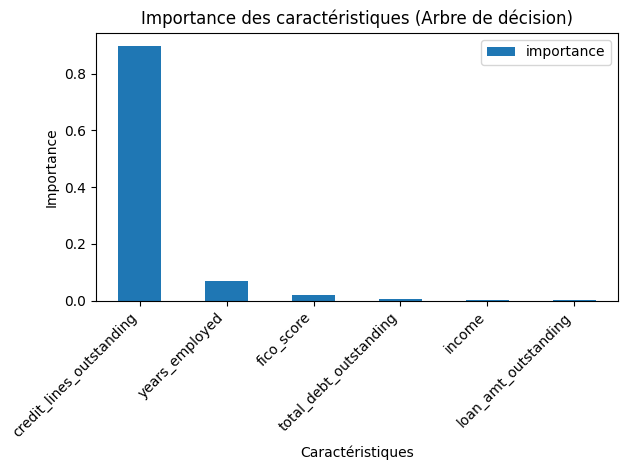

<Figure size 1000x600 with 0 Axes>

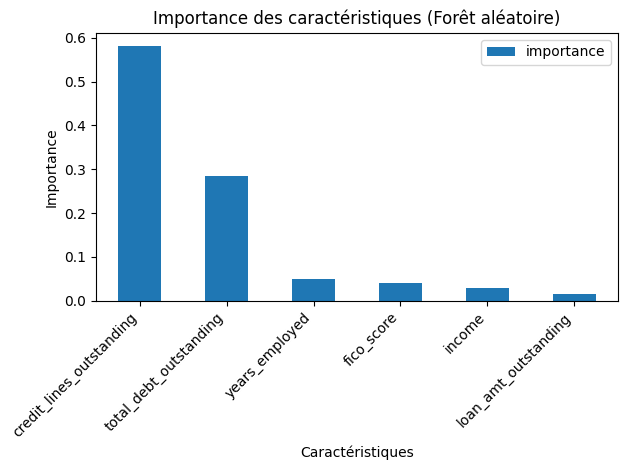

In [26]:
# Pour l'arbre de décision
feature_importance_tree = pd.DataFrame({
    'feature': X.columns,
    'importance': decision_tree_model.feature_importances_
}).sort_values('importance', ascending=False)

# Pour la forêt aléatoire
feature_importance_forest = pd.DataFrame({
    'feature': X.columns,
    'importance': random_forest_model.feature_importances_
}).sort_values('importance', ascending=False)

# Visualisation pour l'arbre de décision
plt.figure(figsize=(10,6))
feature_importance_tree.plot(x='feature', y='importance', kind='bar')
plt.title('Importance des caractéristiques (Arbre de décision)')
plt.xlabel('Caractéristiques')
plt.ylabel('Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Visualisation pour la forêt aléatoire
plt.figure(figsize=(10,6))
feature_importance_forest.plot(x='feature', y='importance', kind='bar')
plt.title('Importance des caractéristiques (Forêt aléatoire)')
plt.xlabel('Caractéristiques')
plt.ylabel('Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

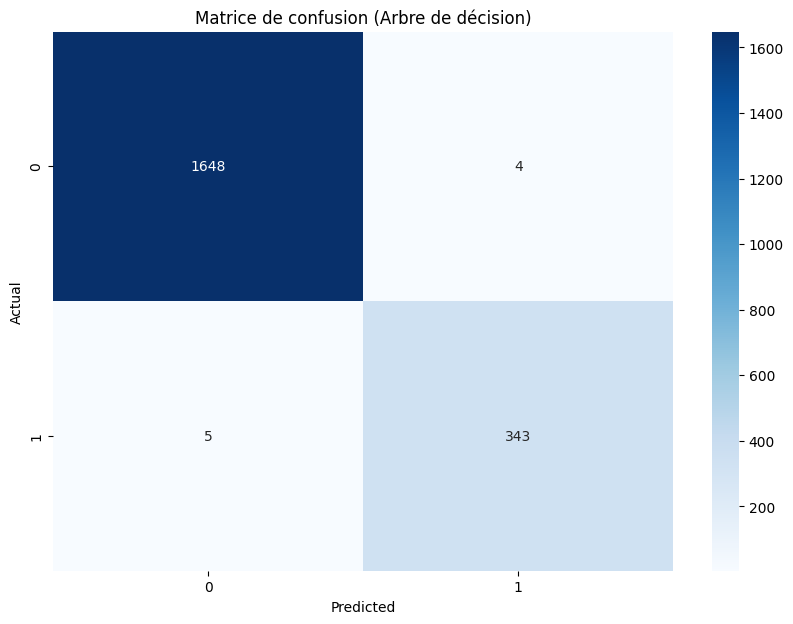

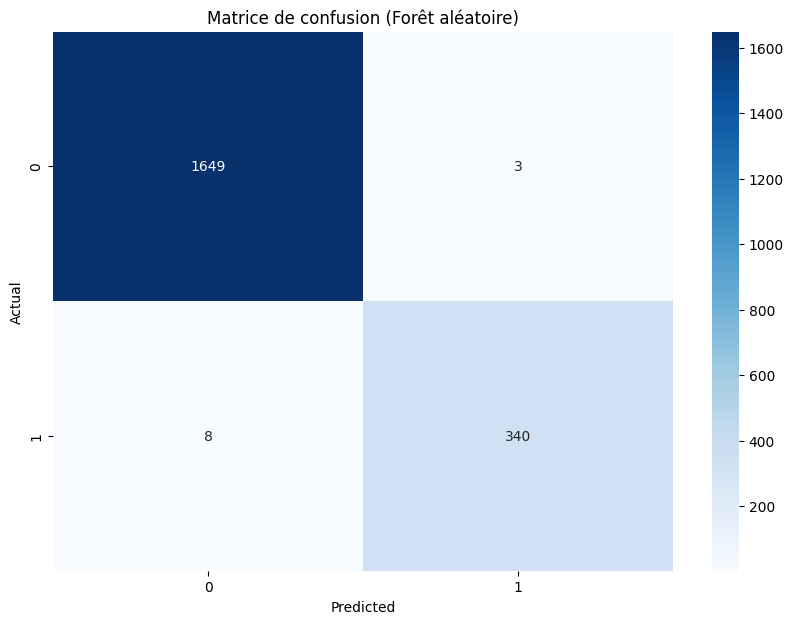

In [27]:
df[column] = df[column].fillna(df[column].median())
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Pour l'arbre de décision
cm_tree = confusion_matrix(y_test, decision_tree_model.predict(X_test))

plt.figure(figsize=(10,7))
sns.heatmap(cm_tree, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Matrice de confusion (Arbre de décision)')
plt.show()

# Pour la forêt aléatoire
cm_forest = confusion_matrix(y_test, random_forest_model.predict(X_test))

plt.figure(figsize=(10,7))
sns.heatmap(cm_forest, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Matrice de confusion (Forêt aléatoire)')
plt.show()

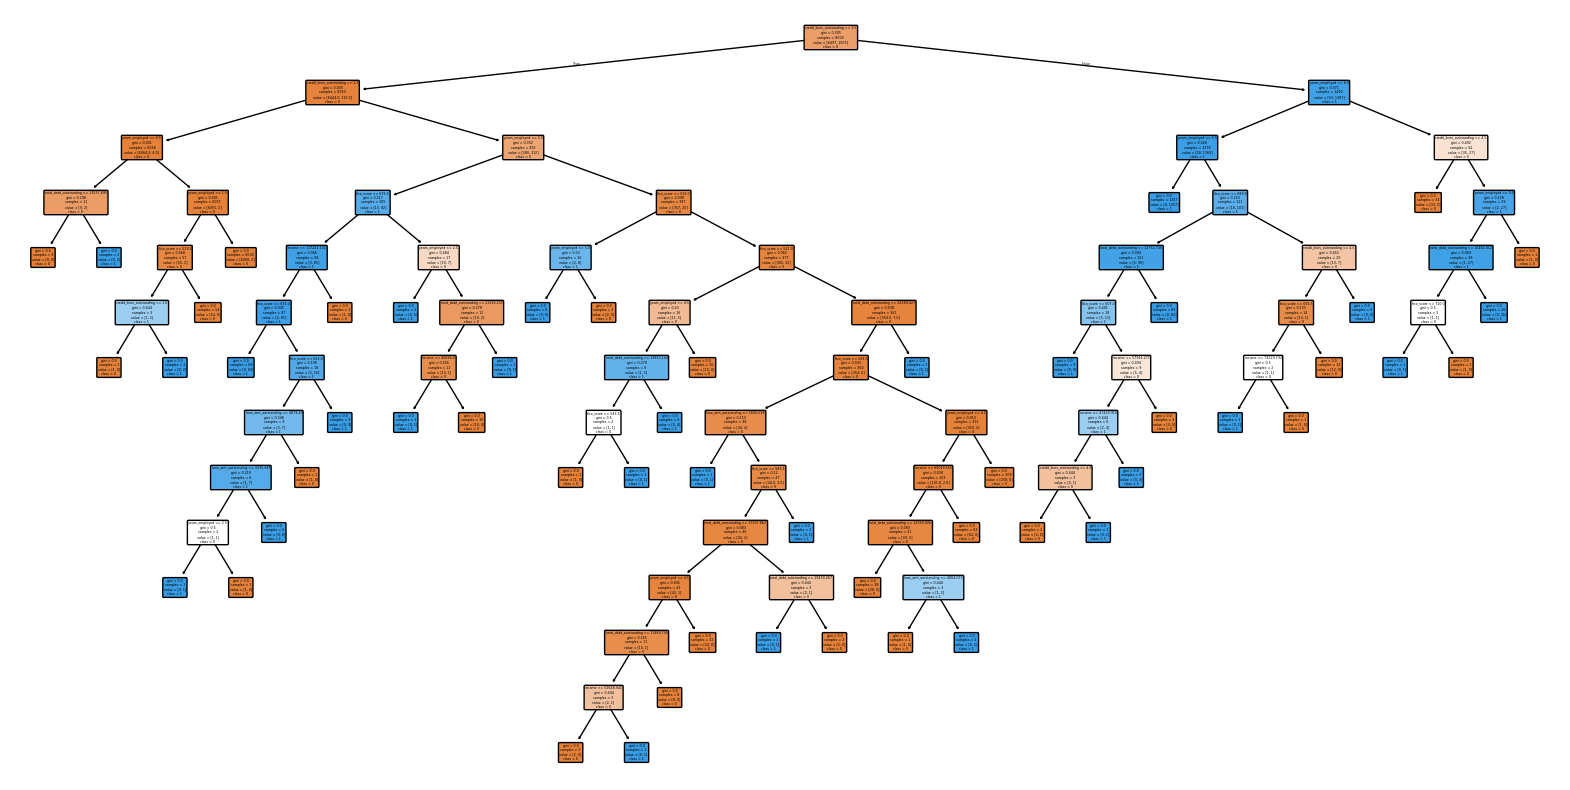

In [28]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))
plot_tree(decision_tree_model, 
          feature_names=list(X.columns),  # Convertir en liste pour s'assurer que ce sont des chaînes
          class_names=[str(c) for c in decision_tree_model.classes_],  # Convertir en chaînes
          filled=True, 
          rounded=True)
plt.show()

##### Effectuez une validation croisée pour obtenir une estimation plus robuste des performances :

In [29]:
from sklearn.model_selection import cross_val_score

# Validation croisée pour l'arbre de décision
cv_scores_tree = cross_val_score(decision_tree_model, X, y, cv=5)
print("Scores de validation croisée (Arbre de décision):", cv_scores_tree)
print("Moyenne des scores:", cv_scores_tree.mean())
print("\n")

# Validation croisée pour la forêt aléatoire
cv_scores_forest = cross_val_score(random_forest_model, X, y, cv=5)
print("Scores de validation croisée (Forêt aléatoire):", cv_scores_forest)
print("Moyenne des scores:", cv_scores_forest.mean())

Scores de validation croisée (Arbre de décision): [0.996 0.998 0.996 0.996 0.994]
Moyenne des scores: 0.9960000000000001


Scores de validation croisée (Forêt aléatoire): [0.996  0.998  0.9945 0.9965 0.9955]
Moyenne des scores: 0.9961


#### Comparaison des deux matrices de confusion

Les deux modèles sont très performants, mais L'Arbre de Décision a des performances légèrement supérieures à la Random Forest, avec une différence de 0.001 (0.1%) sur toutes les métriques.Cependant, il est important de note que la différence de performance entre les deux modèles est très faible (0.1%), ce qui pourrait ne pas être statistiquement significatif.
Bien que l'Arbre de Décision ait des performances légèrement supérieures, la Forêt Aléatoire pourrait être considérée comme le "meilleur" modèle pour les raisons suivantes :

- Elle offre une performance presque identique à l'Arbre de Décision.
- Elle est généralement plus robuste et moins sujette au surapprentissage.
- Elle fournit une importance des caractéristiques potentiellement plus fiable et stable.

### Déploiement de notre modèle 

#### Initialisation du repo Git

In [32]:
# Python
   *.py[cod]
   __pycache__/
   *.so

   # Jupyter Notebook
   .ipynb_checkpoints

   # Virtual Environment
   venv/
   env/

   # MLflow
   mlruns/

   # Model files
   *.joblib
   *.pkl

   # Data
   *.csv
   *.json
   *.xlsx

   # IDE specific files
   .vscode/
   .idea/

   # OS generated files
   .DS_Store
   Thumbs.db

IndentationError: unexpected indent (3002781839.py, line 2)

#### Suivi des Modèles avec MLflow

 Le modèle Random Forest étant le meilleur modèle .Après etude notamment  evaluation de la performance et la matrice de confusion. Nous sommmes dans l'obligation de faire les deploiements sur ce modèle.

In [30]:
pip install streamlit

  Using cached altair-5.4.1-py3-none-any.whl.metadata (9.4 kB)
  Using cached blinker-1.8.2-py3-none-any.whl.metadata (1.6 kB)
  Using cached cachetools-5.5.0-py3-none-any.whl.metadata (5.3 kB)
  Using cached click-8.1.7-py3-none-any.whl.metadata (3.0 kB)
  Using cached protobuf-5.28.2-cp310-abi3-win_amd64.whl.metadata (592 bytes)
     ---------------------------------------- 0.0/1.1 MB ? eta -:--:--
     ---------------------------------------- 1.1/1.1 MB 10.0 MB/s eta 0:00:00
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Using cached requests-2.32.3-py3-none-any.whl.metadata (4.6 kB)
  Using cached toml-0.10.2-py2.py3-none-any.whl.metadata (7.1 kB)
  Using cached typing_extensions-4.12.2-py3-none-any.wh

  error: subprocess-exited-with-error
  
  × Building wheel for pyarrow (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [347 lines of output]
      <string>:34: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
      running bdist_wheel
      running build
      running build_py
      creating build\lib.win-amd64-cpython-313\benchmarks
      copying benchmarks\array_ops.py -> build\lib.win-amd64-cpython-313\benchmarks
      copying benchmarks\common.py -> build\lib.win-amd64-cpython-313\benchmarks
      copying benchmarks\convert_builtins.py -> build\lib.win-amd64-cpython-313\benchmarks
      copying benchmarks\convert_pandas.py -> build\lib.win-amd64-cpython-313\benchmarks
      copying benchmarks\io.py -> build\lib.win-amd64-cpython-313\benchmarks
      copying benchmarks\microbenchmarks.py -> build\lib.win-amd64-cpython-313\benchmarks
      copying benchmarks\parquet.py -> build\lib.win-amd64-cpyt

In [220]:
import mlflow

# Définir l'URL de suivi
mlflow.set_tracking_uri("http://127.0.0.1:5000")

# Votre code MLflow ici
with mlflow.start_run():
    # Votre code pour enregistrer le modèle et les métriques
    pass


2024/09/28 01:25:50 INFO mlflow.tracking._tracking_service.client: 🏃 View run classy-dolphin-707 at: http://127.0.0.1:5000/#/experiments/0/runs/6129e039b3f046d28807c4d3e1ddb5d5.
2024/09/28 01:25:50 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://127.0.0.1:5000/#/experiments/0.


In [221]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, mean_squared_error, r2_score
import mlflow
import mlflow.sklearn
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from mlflow.models.signature import infer_signature

import mlflow

# Définir l'URI de suivi
mlflow.set_tracking_uri("file:///C:/Users/ec/OneDrive/Bureau/PROJET_MLOPS/mlruns")


import os

# Définir la variable d'environnement MLFLOW_TRACKING_URI
os.environ['MLFLOW_TRACKING_URI'] = "file:///C:/Users/ec/OneDrive/Bureau/PROJET_MLOPS/mlruns"

# Vérifier que la variable d'environnement est définie
print(os.environ['MLFLOW_TRACKING_URI'])


file:///C:/Users/ec/OneDrive/Bureau/PROJET_MLOPS/mlruns


In [222]:
# Imputer les valeurs manquantes uniquement pour les colonnes numériques
df_cleaned.select_dtypes(include=['number']).fillna(df_cleaned.mean(numeric_only=True), inplace=True)


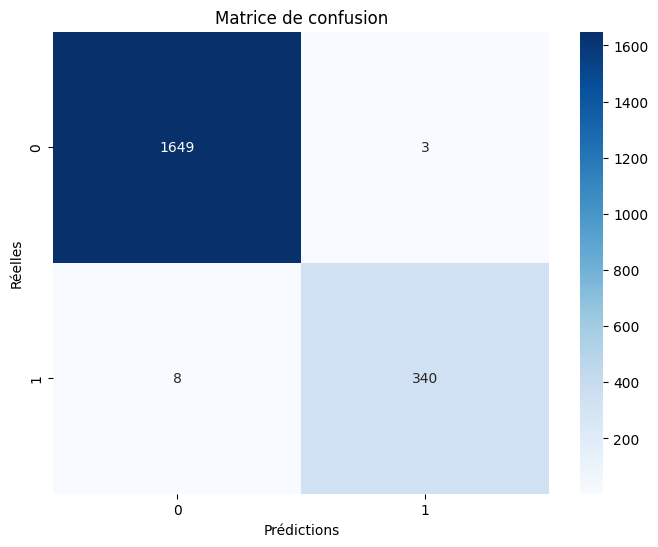

In [223]:

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, mean_squared_error, r2_score, confusion_matrix, classification_report
import mlflow
import mlflow.sklearn
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from mlflow.models.signature import infer_signature

# Supposons que vous avez déjà vos données dans df_cleaned
X = df_cleaned.drop('default', axis=1)  # Remplacez 'default' par le nom de votre variable cible
y = df_cleaned['default']

# Imputer les valeurs manquantes
X.fillna(X.mean(), inplace=True)

# Convertir les colonnes entières en flottantes
for col in X.select_dtypes(include=['int']).columns:
    X[col] = X[col].astype('float64')

# Division des données en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Création et entraînement du modèle
random_forest_model = RandomForestClassifier(random_state=42)
random_forest_model.fit(X_train, y_train)

# Prédictions
y_pred_forest = random_forest_model.predict(X_test)

# Calcul des métriques
accuracy = accuracy_score(y_test, y_pred_forest)
precision = precision_score(y_test, y_pred_forest)
recall = recall_score(y_test, y_pred_forest)
f1 = f1_score(y_test, y_pred_forest)

# Signature et exemple d'entrée
input_example = pd.DataFrame(X_train[:1])
signature = infer_signature(X_train, y_pred_forest)

# Calcul et sauvegarde de la matrice de confusion
conf_matrix = confusion_matrix(y_test, y_pred_forest)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=random_forest_model.classes_, yticklabels=random_forest_model.classes_)
plt.title('Matrice de confusion')
plt.xlabel('Prédictions')
plt.ylabel('Réelles')
plt.savefig("confusion_matrix.png")

# Rapport de classification
class_report = classification_report(y_test, y_pred_forest)



In [224]:
import mlflow

# Vérifier si une exécution est active et la terminer
if mlflow.active_run():
    mlflow.end_run()

# Définir l'URI de suivi vers le serveur local
mlflow.set_tracking_uri("http://127.0.0.1:5000")

# Commencer une nouvelle exécution MLflow
with mlflow.start_run():
    
    # Enregistrer le modèle
    mlflow.sklearn.log_model(random_forest_model, "random_forest_model")
    
    # Enregistrer les paramètres
    mlflow.log_param("random_state", 42)
    
    # Enregistrer les métriques (assurez-vous que ces variables sont définies)
    mlflow.log_metric("accuracy", accuracy)
    mlflow.log_metric("precision", precision)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("f1_score", f1)

    # Enregistrer les artefacts
    mlflow.log_artifact("confusion_matrix.png")
    mlflow.log_text(class_report, "classification_report.txt")


2024/09/28 01:26:01 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
2024/09/28 01:26:01 INFO mlflow.tracking._tracking_service.client: 🏃 View run bedecked-rat-62 at: http://127.0.0.1:5000/#/experiments/0/runs/0007690896354aaf87b73b91254a33e5.
2024/09/28 01:26:01 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://127.0.0.1:5000/#/experiments/0.


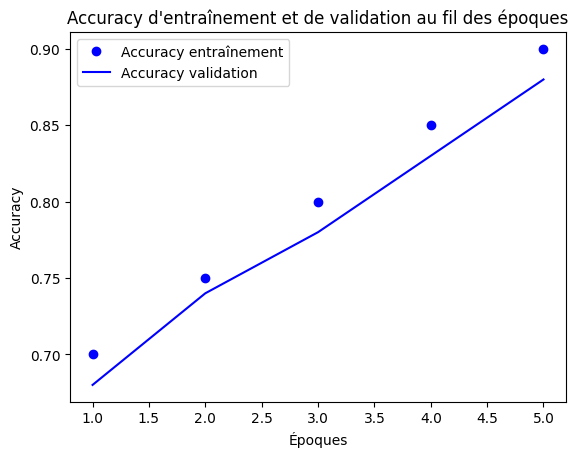

2024/09/28 01:26:02 INFO mlflow.tracking._tracking_service.client: 🏃 View run vaunted-toad-640 at: http://127.0.0.1:5000/#/experiments/0/runs/1fac8f55a9ac4122ac1470ba8e6c9f6a.
2024/09/28 01:26:02 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://127.0.0.1:5000/#/experiments/0.


In [225]:
import mlflow
import matplotlib.pyplot as plt

# Supposons que ces valeurs soient générées pendant l'entraînement
accuracy_values = [0.7, 0.75, 0.8, 0.85, 0.9]  # Exemple d'accuracy d'entraînement
val_accuracy_values = [0.68, 0.74, 0.78, 0.83, 0.88]  # Exemple d'accuracy de validation

# Définir la plage des époques en fonction du nombre de valeurs d'accuracy
epochs = range(1, len(accuracy_values) + 1)

# Commencer une session d'enregistrement avec MLflow
with mlflow.start_run():
    
    # Enregistrer les accuracies dans MLflow pour chaque époque
    for epoch, (train_acc, val_acc) in enumerate(zip(accuracy_values, val_accuracy_values), 1):
        mlflow.log_metric("accuracy_train", train_acc, step=epoch)
        mlflow.log_metric("accuracy_val", val_acc, step=epoch)
    
    # Tracer le graphique
    plt.plot(epochs, accuracy_values, 'bo', label='Accuracy entraînement')
    plt.plot(epochs, val_accuracy_values, 'b', label='Accuracy validation')
    
    # Ajouter des labels et une légende
    plt.title('Accuracy d\'entraînement et de validation au fil des époques')
    plt.xlabel('Époques')
    plt.ylabel('Accuracy')
    plt.legend()
    
    # Enregistrer le graphique sous forme d'image dans MLflow
    plt.savefig('accuracy_plot.png')
    
    # Loguer le graphique dans MLflow
    mlflow.log_artifact('accuracy_plot.png')
    
    # Afficher le graphique
    plt.show()


In [226]:
import matplotlib.pyplot as plt
import mlflow
import numpy as np
from sklearn.metrics import roc_curve, auc

# Simuler des valeurs pour l'exemple
accuracy_values = [0.8, 0.85, 0.88, 0.9, 0.92]
val_accuracy_values = [0.78, 0.82, 0.84, 0.86, 0.88]
loss_values = [0.5, 0.4, 0.35, 0.3, 0.25]
val_loss_values = [0.55, 0.45, 0.4, 0.35, 0.3]

# Commencer une session d'enregistrement avec MLflow
try:
    mlflow.start_run()
    
    # Enregistrer les accuracies dans MLflow pour chaque époque
    for epoch, (train_acc, val_acc) in enumerate(zip(accuracy_values, val_accuracy_values), 1):
        mlflow.log_metric("accuracy_train", train_acc, step=epoch)
        mlflow.log_metric("accuracy_val", val_acc, step=epoch)

    # Courbe ROC et AUC
    y_prob = random_forest_model.predict_proba(X_test)[:, 1]  # Remplacez ceci par votre modèle
    fpr, tpr, _ = roc_curve(y_test, y_prob)  # y_test est votre vérité terrain
    roc_auc = auc(fpr, tpr)
    
    plt.figure()
    plt.plot(fpr, tpr, color='darkorange', lw=2, label='Courbe ROC (AUC = %0.2f)' % roc_auc)
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Taux de faux positifs')
    plt.ylabel('Taux de vrais positifs')
    plt.title('Caractéristique de fonctionnement du récepteur')
    plt.legend(loc="lower right")
    
    # Enregistrer la courbe ROC
    plt.savefig('roc_curve.png')
    mlflow.log_artifact('roc_curve.png')
    plt.close()  # Fermer la figure après l'enregistrement

    # Importance des caractéristiques
    importances = random_forest_model.feature_importances_  # Remplacez ceci par votre modèle
    indices = np.argsort(importances)[::-1]
    
    plt.figure()
    plt.title("Importance des caractéristiques")
    plt.bar(range(X_train.shape[1]), importances[indices], align="center")
    plt.xticks(range(X_train.shape[1]), indices)
    plt.xlim([-1, X_train.shape[1]])
    
    # Enregistrer l'importance des caractéristiques
    plt.savefig('feature_importance.png')
    mlflow.log_artifact('feature_importance.png')
    plt.close()  # Fermer la figure après l'enregistrement

finally:
    # Terminer la session MLflow, même si une erreur se produit
    mlflow.end_run()


2024/09/28 01:26:03 INFO mlflow.tracking._tracking_service.client: 🏃 View run rambunctious-gnu-96 at: http://127.0.0.1:5000/#/experiments/0/runs/67afac022115402fa56505658b68451e.
2024/09/28 01:26:03 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://127.0.0.1:5000/#/experiments/0.


#### Déploiement Streamlit

#### Création de l’application Streamlit

In [272]:
from sklearn.ensemble import RandomForestClassifier
import pickle

# Train your model
model = RandomForestClassifier()
model.fit(X_train, y_train)

# Save the model
with open('random_forest_model.pkl', 'wb') as model_file:
    pickle.dump(model, model_file)


In [273]:
import pickle

model_path = r'c:\Users\ec\OneDrive\Bureau\PROJET_MLOPS\random_forest_model.pkl'
with open(model_path, 'rb') as model_file:
    model = pickle.load(model_file)
print(type(model))  # This should print the type of the model, e.g., <class 'sklearn.ensemble._forest.RandomForestClassifier'>


<class 'sklearn.ensemble._forest.RandomForestClassifier'>
